In [ ]:
import sys
import os
from tqdm import tqdm
import cv2
from matplotlib import pyplot as plt
import numpy as np
import viser

parent_dir = os.path.dirname(os.getcwd())
sys.path.insert(0, parent_dir)

os.environ["MOMENTUM_ENABLED"] = "1"

from utils import (
    setup_sam_3d_body, setup_visualizer, 
    visualize_2d_results, visualize_3d_mesh, save_mesh_results, 
    display_results_grid, process_image_with_mask
)

# Set up SAM 3D Body estimator using local checkpoint
checkpoint_dir = os.path.join(parent_dir, "checkpoints", "sam-3d-body-dinov3")
estimator = setup_sam_3d_body(checkpoint_dir=checkpoint_dir)
# Set up visualizer
visualizer = setup_visualizer()

/home/rikhat/human_global_motion/sam-3d-body/sam_3d_body/models/heads/mhr_head.py:29: UserWarning: Momentum is not enabled
  warnings.warn("Momentum is not enabled")
/home/rikhat/human_global_motion/sam-3d-body/sam_3d_body/models/heads/mhr_head.py:33: UserWarning: Momentum is not enabled
  warnings.warn("Momentum is not enabled")


Loading SAM 3D Body model from local checkpoint: /home/rikhat/human_global_motion/sam-3d-body/checkpoints/sam-3d-body-dinov3...
CKPT PATH: /home/rikhat/human_global_motion/sam-3d-body/checkpoints/sam-3d-body-dinov3/model.ckpt
MHR PATH: /home/rikhat/human_global_motion/sam-3d-body/checkpoints/sam-3d-body-dinov3/assets/mhr_model.pt
Loading SAM 3D Body model...


Using cache found in /home/rikhat/.cache/torch/hub/facebookresearch_dinov3_main
Ignored kwargs: {'drop_path': 0.1}
The model and loaded state dict do not match exactly

missing keys in source state_dict: backbone.encoder.mask_token, head_pose.hand_pose_comps_ori, head_pose.mhr.face_expressions_model.shape_vectors, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.0.sparse_indices, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.0.sparse_weight, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.2.weight, head_pose.mhr.character_torch.skeleton.joint_translation_offsets, head_pose.mhr.character_torch.skeleton.joint_prerotations, head_pose.mhr.character_torch.skeleton.pmi, head_pose.mhr.character_torch.skeleton.joint_parents, head_pose.mhr.character_torch.mesh.rest_vertices, head_pose.mhr.character_torch.mesh.faces, head_pose.mhr.character_torch.mesh.texcoords, head_pose.mhr.character_torch.mesh.texcoord_faces, head_pose.mhr.character_torch.parameter_transform.parame

Loading human detector from vitdet...
########### Using human detector: ViTDet...


/home/rikhat/miniconda3/envs/mhr/lib/python3.12/site-packages/detectron2/config/lazy.py:167: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return old_import(name, globals, locals, fromlist=fromlist, level=level)
/home/rikhat/miniconda3/envs/mhr/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading FOV estimator from moge2...
########### Using fov estimator: MoGe2...
Mask-condition inference is not supported...
Setup complete!
  Human detector: ✓
  Human segmentor: ✗ (mask inference disabled)
  FOV estimator: ✓


In [10]:
dataset_base_path = "/media/rikhat/Hard/datasets/DECO"

mhr_data_path = "../../datasets/daimon_mhr_contact/hot_dca_trainval_mhr.npz"
mhr_data = np.load(mhr_data_path, allow_pickle=True)

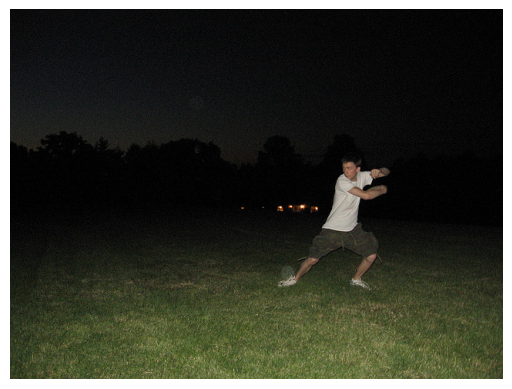

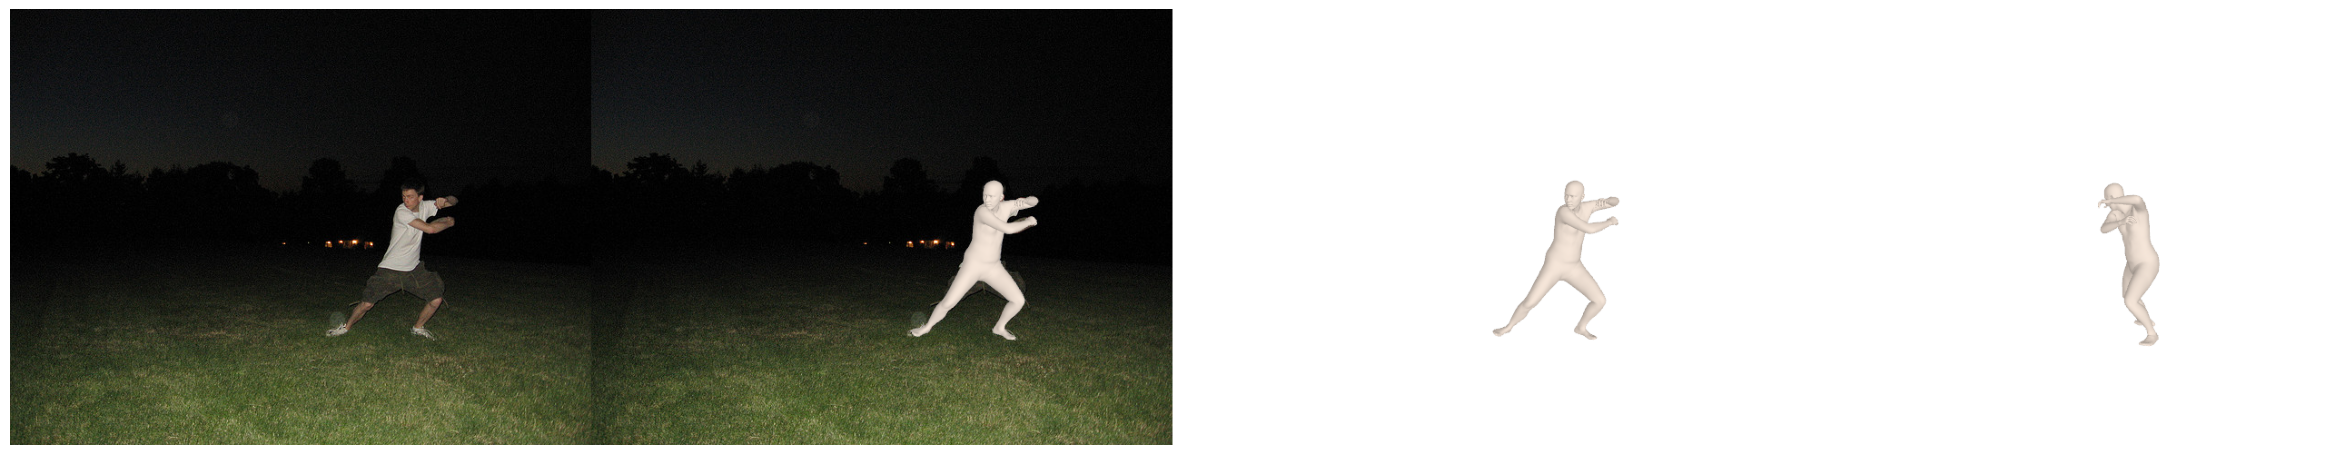

In [13]:
id = 0

img_path = os.path.join(dataset_base_path, mhr_data["imgname"][id])
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


output = estimator.process_one_image(img_path)
mesh_results = visualize_3d_mesh(img, output, estimator.faces)


plt.imshow(img)
plt.axis('off')
plt.show()

plt.figure(figsize=(30, 10))
plt.imshow(mesh_results[0])
plt.axis('off')
plt.show()


In [ ]:
server = viser.ViserServer()

╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Connection opened (0, 1 total), 5 persistent messages

In [26]:
print(mhr_data["contact_label"][id])
print(mhr_data["contact_label_objectwise"][id].keys())  


[0 0 0 ... 1 1 1]
dict_keys(['frisbee', 'supporting'])


In [28]:
vertices = output[0]["pred_vertices"]
faces = estimator.faces

server.scene.add_mesh_simple(
    name="mesh",
    vertices=vertices,
    faces=faces,
    color=(90, 200, 255),
    wireframe=False,
)



MeshHandle(vertices=array([[ 0.10349663, -1.5291673 , -0.29939654],
       [ 0.11022878, -1.5725782 , -0.31854555],
       [ 0.10353281, -1.5373633 , -0.30329913],
       ...,
       [-0.63208103, -0.3090695 ,  0.11010729],
       [-0.63189626, -0.3098028 ,  0.11396482],
       [-0.6313826 , -0.31025553,  0.11691528]],
      shape=(18439, 3), dtype=float32), faces=array([[ 3997,  3895,  5229],
       [ 3792,  3895,  4722],
       [ 3792,  3794,  4721],
       ...,
       [18423, 18379, 18380],
       [18417, 18418, 18419],
       [18417, 18419, 18420]], shape=(36874, 3), dtype=uint32), color=(90, 200, 255), wireframe=False, opacity=None, flat_shading=False, side='front', material='standard', cast_shadow=True, receive_shadow=True)

In [34]:
for name, vertices_id in mhr_data["contact_label_objectwise"][id].items():
    server.scene.add_point_cloud(
        name=name,
        points=vertices[vertices_id],
        colors=(255, 0, 0),
        point_size=0.005,
    )

